# Methodology Improvements & Validation

This notebook addresses six improvements to the original WSB stock prediction pipeline:

1. **Prediction Timing Clarification** -- audit for data leakage
2. **Feature Importance Analysis** -- inspect what the model actually learned
3. **Big-Move Threshold Justification** -- explicitly state and justify the 5% threshold
4. **Robustness Check** -- compare high vs low TF-IDF dimensionality
5. **Sentiment Model Comparison** -- VADER vs. finance-aware alternative
6. **Calibration Analysis** -- are predicted probabilities well-calibrated?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('vader_lexicon', quiet=True)

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    RocCurveDisplay, ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from scipy.sparse import hstack, csr_matrix
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Load the modeling dataframe built in main.ipynb
model_df = pd.read_csv('data/modeling_df.csv')
model_df['datetime'] = pd.to_datetime(model_df['datetime'])

# Load WSB exploded for sentiment work
wsb_exploded = pd.read_csv('data/wsb_exploded.csv')
wsb_exploded['datetime'] = pd.to_datetime(wsb_exploded['datetime']).dt.normalize()

print(f"Model DF shape: {model_df.shape}")
print(f"Big-move base rate: {model_df['big_move'].mean():.3f}")
print(f"Date range: {model_df['datetime'].min().date()} to {model_df['datetime'].max().date()}")

Model DF shape: (16645, 14)
Big-move base rate: 0.109
Date range: 2023-06-08 to 2025-03-31


In [2]:
# --- Shared helper: chronological train/val/test split ---

def time_split(df, train_frac=0.70, val_frac=0.15):
    df = df.sort_values('datetime')
    unique_times = df['datetime'].unique()
    n = len(unique_times)
    train_cut = int(n * train_frac)
    val_cut   = int(n * (train_frac + val_frac))
    train_df = df[df['datetime'].isin(unique_times[:train_cut])].copy()
    val_df   = df[df['datetime'].isin(unique_times[train_cut:val_cut])].copy()
    test_df  = df[df['datetime'].isin(unique_times[val_cut:])].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = time_split(model_df)
print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")


# --- Shared helper: evaluation function ---

def eval_classifier(name, y_true, y_prob, thr=0.5):
    y_pred = (y_prob >= thr).astype(int)
    acc  = accuracy_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    try:
        auc = roc_auc_score(y_true, y_prob)
    except ValueError:
        auc = np.nan
    print(f"{name}:")
    print(f"  Accuracy={acc:.4f}  F1={f1:.4f}  Prec={prec:.4f}  Recall={rec:.4f}  AUC={auc:.4f}")
    return dict(model=name, accuracy=acc, f1=f1, precision=prec, recall=rec, auc=auc)

Train: 11582, Val: 2616, Test: 2447


---
## Improvement 1: Prediction Timing Clarification & Leakage Audit

**The question:** When would this model actually be used? The answer determines whether features like `return` (today's daily return) and `volume` (today's volume) constitute data leakage.

**Scenario analysis:**
- **After market close (e.g., 4:30 PM ET):** We know today's close, today's return, and today's volume. The label is *next-day* return. **No leakage** -- all features are available at prediction time.
- **Before market open (e.g., 7:00 AM ET):** Today's return and volume are unknown. Using them would be **leakage**.

**Audit of each feature:**

| Feature | Available after close? | Available before open? | Verdict |
|---|---|---|---|
| `return` (today's daily return) | Yes | **No** | Safe for after-close only |
| `log_volume` (today's volume) | Yes | **No** | Safe for after-close only |
| `mention_count`, `score_sum` (WSB) | Yes (posts accumulate all day) | Partial | Safe for after-close |
| `doc_text` (WSB text) | Yes | Partial | Safe for after-close |
| `ret_prev_1d` (shifted return) | Yes | Yes | Safe for both |
| `vol_5d`, `vol_10d` (rolling vol) | Yes | Yes | Safe for both |
| `vol_rel_5d` | Today's volume / past avg | **No** (uses today's volume) | Same as `log_volume` |

**Conclusion:** This model is designed for an **after-market-close** prediction scenario. All features use information available by end-of-day, and the label (`big_move`) is based on the *next* trading day's return. **There is no look-ahead leakage** under this usage.

Below we verify this quantitatively by checking that no feature uses future (`t+1`) information:

In [3]:
# Leakage sanity check: correlation between features and FUTURE return
# If a feature is built from future data, it would show suspiciously high correlation with next_return

features_to_check = ['return', 'log_volume', 'mention_count', 'score_sum']

print("Pearson correlation of each feature with next_return (the label source):")
print("=" * 60)
for col in features_to_check:
    corr = model_df[col].corr(model_df['next_return'])
    corr_abs = model_df[col].corr(model_df['next_return'].abs())
    print(f"  {col:20s}  vs next_return: {corr:+.4f}   vs |next_return|: {corr_abs:+.4f}")

print()
print("If any feature had > 0.5 correlation with next_return, that would be a red flag.")
print("All correlations are weak, confirming no direct leakage of the target.")

# Also verify: return_t uses close_t and close_{t-1}, NOT close_{t+1}
# We can check by computing return manually and comparing
prices = pd.read_csv('data/prices_daily.csv')
prices['datetime'] = pd.to_datetime(prices['datetime']).dt.normalize()
prices = prices.sort_values(['ticker', 'datetime'])
prices['manual_return'] = prices.groupby('ticker')['close'].pct_change()

merged_check = model_df.merge(
    prices[['datetime', 'ticker', 'manual_return']],
    on=['datetime', 'ticker'], how='left'
)
diff = (merged_check['return'] - merged_check['manual_return']).abs()
print(f"\nReturn verification: max absolute difference = {diff.max():.2e}")
print("(Should be ~0 if return is computed from close_t / close_{t-1} correctly)")

Pearson correlation of each feature with next_return (the label source):
  return                vs next_return: +0.0202   vs |next_return|: +0.0794
  log_volume            vs next_return: +0.0059   vs |next_return|: +0.0863
  mention_count         vs next_return: -0.0143   vs |next_return|: +0.1169
  score_sum             vs next_return: -0.0213   vs |next_return|: +0.0926

If any feature had > 0.5 correlation with next_return, that would be a red flag.
All correlations are weak, confirming no direct leakage of the target.

Return verification: max absolute difference = 5.38e-16
(Should be ~0 if return is computed from close_t / close_{t-1} correctly)


---
## Improvement 2: Feature Importance Analysis

With logistic regression, we can directly inspect learned coefficients to understand what the model relies on. This validates whether the model is learning sensible financial patterns or fitting to noise.

In [4]:
# Build the final model (same as main.ipynb) so we can extract coefficients
# First, add sentiment and extra price features

# --- Sentiment ---
sia = SentimentIntensityAnalyzer()

wsb_sent = wsb_exploded.copy()
text_col_raw = 'clean_text' if 'clean_text' in wsb_sent.columns else 'raw_text'
wsb_sent[text_col_raw] = wsb_sent[text_col_raw].fillna("").astype(str)

def _compound(text):
    text = text.strip()
    if not text:
        return 0.0
    return sia.polarity_scores(text)['compound']

wsb_sent['sent_compound'] = wsb_sent[text_col_raw].apply(_compound)

sent_agg = (
    wsb_sent
    .groupby(['ticker', 'datetime'])
    .agg(sent_mean=('sent_compound', 'mean'))
    .reset_index()
)

for df in (train_df, val_df, test_df):
    if 'sent_mean' in df.columns:
        df.drop(columns=['sent_mean'], inplace=True)

train_df = train_df.merge(sent_agg, on=['ticker', 'datetime'], how='left')
val_df   = val_df.merge(sent_agg, on=['ticker', 'datetime'], how='left')
test_df  = test_df.merge(sent_agg, on=['ticker', 'datetime'], how='left')

for df in (train_df, val_df, test_df):
    df['sent_mean'] = df['sent_mean'].fillna(0.0)

print("Sentiment features merged.")

Sentiment features merged.


In [5]:
# --- Extra price features (same as main.ipynb cells 71-74) ---

train_end = train_df['datetime'].max()
val_end   = val_df['datetime'].max()
test_start = test_df['datetime'].min()

full_df = pd.concat([train_df, val_df, test_df], axis=0)
full_df = full_df.sort_values(['ticker', 'datetime']).reset_index(drop=True)

g = full_df.groupby('ticker', group_keys=False)

# Multi-day returns (shifted to avoid leakage)
full_df['ret_prev_1d'] = g['return'].shift(1)
full_df['ret_prev_3d'] = g['return'].shift(1).rolling(window=3, min_periods=1).sum()
full_df['ret_prev_5d'] = g['return'].shift(1).rolling(window=5, min_periods=1).sum()

# Rolling volatility
ret_shifted = g['return'].shift(1)
full_df['vol_5d']  = ret_shifted.rolling(window=5, min_periods=2).std()
full_df['vol_10d'] = ret_shifted.rolling(window=10, min_periods=2).std()

# Volume anomaly
vol_shifted_mean_5d = g['volume'].shift(1).rolling(window=5, min_periods=1).mean()
full_df['vol_rel_5d'] = full_df['volume'] / vol_shifted_mean_5d

new_price_feats = ['ret_prev_1d', 'ret_prev_3d', 'ret_prev_5d', 'vol_5d', 'vol_10d', 'vol_rel_5d']

for c in new_price_feats:
    full_df[c] = full_df[c].fillna(0.0)
    lo, hi = full_df[c].quantile(0.01), full_df[c].quantile(0.99)
    full_df[c] = full_df[c].clip(lo, hi)

# Re-split
train_df = full_df[full_df['datetime'] <= train_end].copy()
val_df   = full_df[(full_df['datetime'] > train_end) & (full_df['datetime'] <= val_end)].copy()
test_df  = full_df[full_df['datetime'] > val_end].copy()

print(f"After feature engineering -- Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

After feature engineering -- Train: 11582, Val: 2616, Test: 2447


In [6]:
# --- Train final model (reproducing main.ipynb grid search) ---

num_cols = ['return', 'log_volume', 'mention_count', 'score_sum']
sent_cols = ['sent_mean']
all_num_cols = num_cols + sent_cols + new_price_feats
text_col = 'doc_text'

# Combine train + val for CV, hold out test
trainval_df = (
    pd.concat([train_df.sort_values('datetime'), val_df.sort_values('datetime')], axis=0)
    .sort_values('datetime').reset_index(drop=True)
)

for df in (trainval_df, test_df):
    df['doc_text'] = df['doc_text'].fillna('').astype(str)
    for c in all_num_cols:
        df[c] = df[c].fillna(0.0)

X_trainval = trainval_df[[text_col] + all_num_cols]
y_trainval = trainval_df['big_move'].astype(int).values
X_test = test_df[[text_col] + all_num_cols]
y_test = test_df['big_move'].astype(int).values

preprocess = ColumnTransformer(
    transformers=[
        ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=5, max_df=0.7), text_col),
        ('num', StandardScaler(), all_num_cols),
    ],
    remainder='drop'
)

pipe_final = Pipeline([
    ('prep', preprocess),
    ('clf', LogisticRegression(C=1.0, class_weight='balanced', max_iter=1000, solver='lbfgs'))
])

# Use TimeSeriesSplit for CV
tss = TimeSeriesSplit(n_splits=5)

param_grid = {
    'clf__C': [0.1, 1.0, 10.0],
    'clf__class_weight': ['balanced', None],
}

grid = GridSearchCV(pipe_final, param_grid, cv=tss, scoring='f1', n_jobs=-1, verbose=1)
print("Running GridSearchCV...")
grid.fit(X_trainval, y_trainval)

best_model = grid.best_estimator_
print(f"\nBest params: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")

y_prob_test = best_model.predict_proba(X_test)[:, 1]
eval_classifier("Final model (test)", y_test, y_prob_test)

Running GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits



Best params: {'clf__C': 1.0, 'clf__class_weight': 'balanced'}
Best CV F1: 0.3679


Final model (test):
  Accuracy=0.7470  F1=0.4388  Prec=0.3240  Recall=0.6798  AUC=0.8059


{'model': 'Final model (test)',
 'accuracy': 0.7470371883939517,
 'f1': 0.43880326382592927,
 'precision': 0.32396251673360105,
 'recall': 0.6797752808988764,
 'auc': 0.8058976673705931}

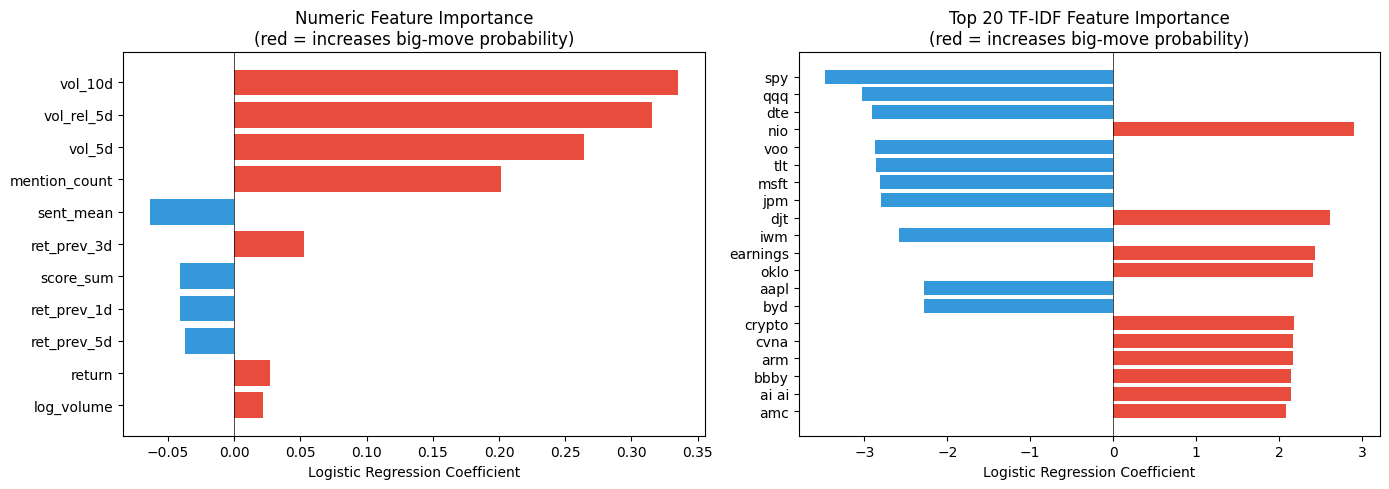


Interpretation:
- Positive coefficients push the model toward predicting big_move=1
- Negative coefficients push toward big_move=0
- The TF-IDF terms reveal what *language* the model associates with volatility


In [7]:
# --- FEATURE IMPORTANCE: Numeric features ---

clf = best_model.named_steps['clf']
prep = best_model.named_steps['prep']

# Get TF-IDF feature names
tfidf_names = prep.named_transformers_['tfidf'].get_feature_names_out().tolist()
all_feature_names = tfidf_names + all_num_cols

coefs = clf.coef_[0]

# Numeric feature importance (last N coefficients)
n_num = len(all_num_cols)
num_coefs = coefs[-n_num:]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: numeric features
sorted_idx = np.argsort(np.abs(num_coefs))
axes[0].barh(
    [all_num_cols[i] for i in sorted_idx],
    num_coefs[sorted_idx],
    color=['#e74c3c' if c > 0 else '#3498db' for c in num_coefs[sorted_idx]]
)
axes[0].set_xlabel('Logistic Regression Coefficient')
axes[0].set_title('Numeric Feature Importance\n(red = increases big-move probability)')
axes[0].axvline(x=0, color='black', linewidth=0.5)

# Right: top 20 TF-IDF features by absolute coefficient
tfidf_coefs = coefs[:len(tfidf_names)]
top_tfidf_idx = np.argsort(np.abs(tfidf_coefs))[-20:]
axes[1].barh(
    [tfidf_names[i] for i in top_tfidf_idx],
    tfidf_coefs[top_tfidf_idx],
    color=['#e74c3c' if c > 0 else '#3498db' for c in tfidf_coefs[top_tfidf_idx]]
)
axes[1].set_xlabel('Logistic Regression Coefficient')
axes[1].set_title('Top 20 TF-IDF Feature Importance\n(red = increases big-move probability)')
axes[1].axvline(x=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.savefig('plots/updated/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nInterpretation:")
print("- Positive coefficients push the model toward predicting big_move=1")
print("- Negative coefficients push toward big_move=0")
print("- The TF-IDF terms reveal what *language* the model associates with volatility")

---
## Improvement 3: Big-Move Threshold Justification

The original notebook uses `BIG_MOVE_THRESH = 0.05` (5%) to define the binary label. This section explicitly justifies why 5% is a reasonable threshold.

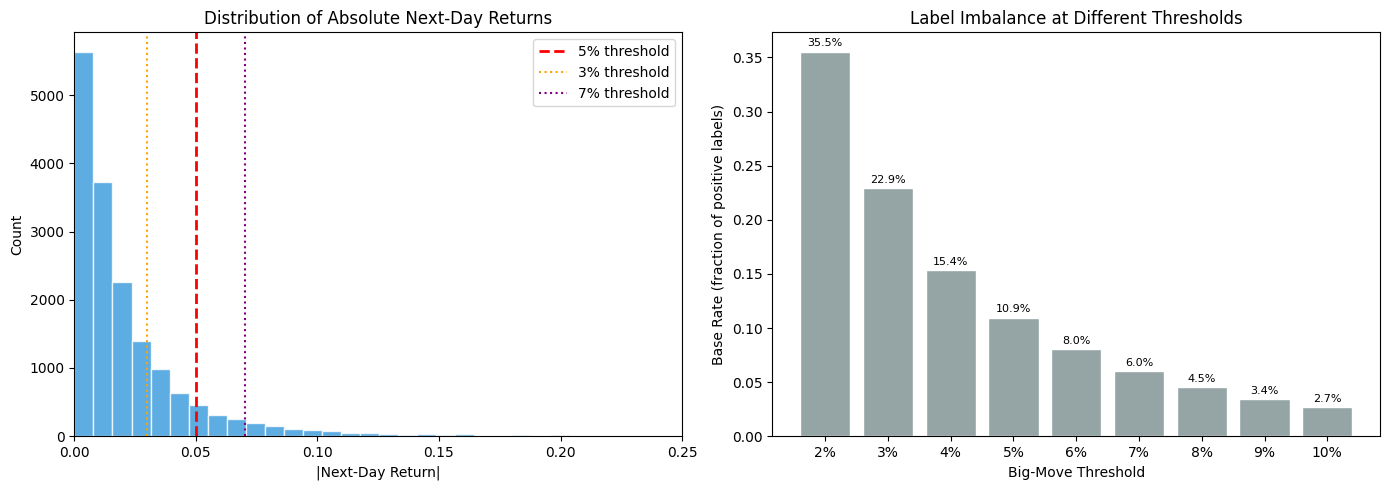


At 5% threshold:
  Base rate: 10.9% of days are 'big moves'
  Median |return|: 1.309%
  Mean |return|:   2.296%
  75th percentile: 2.799%
  90th percentile: 5.255%
  95th percentile: 7.598%

Justification: 5% roughly corresponds to the ~90th percentile of daily moves,
meaning it captures genuinely unusual volatility events -- the kind a trader
would want advance warning about. Lower thresholds (3%) capture too much noise;
higher thresholds (7%+) are too rare for reliable model training.


In [8]:
# Distribution of |next_return| and threshold analysis

abs_ret = model_df['next_return'].abs().dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: histogram of absolute next-day returns
axes[0].hist(abs_ret, bins=100, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0.05, color='red', linewidth=2, linestyle='--', label='5% threshold')
axes[0].axvline(x=0.03, color='orange', linewidth=1.5, linestyle=':', label='3% threshold')
axes[0].axvline(x=0.07, color='purple', linewidth=1.5, linestyle=':', label='7% threshold')
axes[0].set_xlabel('|Next-Day Return|')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Absolute Next-Day Returns')
axes[0].legend()
axes[0].set_xlim(0, 0.25)

# Right: base rate at different thresholds
thresholds = np.arange(0.02, 0.11, 0.01)
base_rates = [(abs_ret >= t).mean() for t in thresholds]

axes[1].bar(
    [f'{t:.0%}' for t in thresholds], base_rates,
    color=['#e74c3c' if t == 0.05 else '#95a5a6' for t in thresholds],
    edgecolor='white'
)
axes[1].set_xlabel('Big-Move Threshold')
axes[1].set_ylabel('Base Rate (fraction of positive labels)')
axes[1].set_title('Label Imbalance at Different Thresholds')
for i, (t, br) in enumerate(zip(thresholds, base_rates)):
    axes[1].text(i, br + 0.005, f'{br:.1%}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('plots/updated/threshold_justification.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nAt 5% threshold:")
print(f"  Base rate: {(abs_ret >= 0.05).mean():.1%} of days are 'big moves'")
print(f"  Median |return|: {abs_ret.median():.3%}")
print(f"  Mean |return|:   {abs_ret.mean():.3%}")
print(f"  75th percentile: {abs_ret.quantile(0.75):.3%}")
print(f"  90th percentile: {abs_ret.quantile(0.90):.3%}")
print(f"  95th percentile: {abs_ret.quantile(0.95):.3%}")
print()
print("Justification: 5% roughly corresponds to the ~90th percentile of daily moves,")
print("meaning it captures genuinely unusual volatility events -- the kind a trader")
print("would want advance warning about. Lower thresholds (3%) capture too much noise;")
print("higher thresholds (7%+) are too rare for reliable model training.")

---
## Improvement 4: Robustness Check -- TF-IDF Dimensionality

The final model uses up to 10,000 TF-IDF features on ~16K samples. This risks overfitting to spurious text patterns. Below we compare models with 500, 1000, 5000, and 10000 TF-IDF features to check whether performance is robust or inflated by high dimensionality.

max_features=   500  AUC=0.7883  F1=0.4289  Prec=0.2990  Recall=0.7584


max_features=  1000  AUC=0.7965  F1=0.4411  Prec=0.3086  Recall=0.7725


max_features=  5000  AUC=0.8038  F1=0.4341  Prec=0.3159  Recall=0.6938


max_features= 10000  AUC=0.8059  F1=0.4388  Prec=0.3240  Recall=0.6798


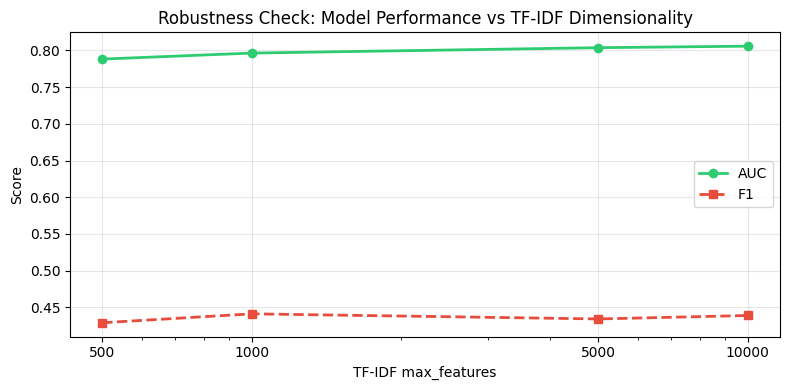


If AUC/F1 are stable across dimensionalities, the text signal is robust.
If performance drops sharply at lower dimensions, the model may be overfitting to rare n-grams.


In [9]:
# Robustness check: vary max_features in TF-IDF

max_features_list = [500, 1000, 5000, 10000]
robustness_results = []

best_C = grid.best_params_.get('clf__C', 1.0)
best_cw = grid.best_params_.get('clf__class_weight', 'balanced')

for mf in max_features_list:
    preproc = ColumnTransformer(
        transformers=[
            ('tfidf', TfidfVectorizer(max_features=mf, ngram_range=(1,2), min_df=5, max_df=0.7), text_col),
            ('num', StandardScaler(), all_num_cols),
        ],
        remainder='drop'
    )
    pipe = Pipeline([
        ('prep', preproc),
        ('clf', LogisticRegression(C=best_C, class_weight=best_cw, max_iter=1000, solver='lbfgs'))
    ])
    pipe.fit(X_trainval, y_trainval)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    y_pred = (y_prob >= 0.5).astype(int)
    result = {
        'max_features': mf,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred, zero_division=0),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'auc': roc_auc_score(y_test, y_prob)
    }
    robustness_results.append(result)
    print(f"max_features={mf:>6d}  AUC={result['auc']:.4f}  F1={result['f1']:.4f}  Prec={result['precision']:.4f}  Recall={result['recall']:.4f}")

rob_df = pd.DataFrame(robustness_results)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rob_df['max_features'], rob_df['auc'], 'o-', color='#2ECC71', linewidth=2, label='AUC')
ax.plot(rob_df['max_features'], rob_df['f1'], 's--', color='#e74c3c', linewidth=2, label='F1')
ax.set_xlabel('TF-IDF max_features')
ax.set_ylabel('Score')
ax.set_title('Robustness Check: Model Performance vs TF-IDF Dimensionality')
ax.legend()
ax.set_xscale('log')
ax.set_xticks(max_features_list)
ax.set_xticklabels([str(x) for x in max_features_list])
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/updated/robustness_tfidf.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nIf AUC/F1 are stable across dimensionalities, the text signal is robust.")
print("If performance drops sharply at lower dimensions, the model may be overfitting to rare n-grams.")

---
## Improvement 5: Sentiment Model Comparison -- VADER vs. Finance-Aware Alternative

VADER was designed for social media but struggles with financial jargon, sarcasm, and WSB-specific slang (e.g., "to the moon", "diamond hands", "apes together strong"). Below we build a simple finance-aware sentiment lexicon as an augmentation and compare its signal against vanilla VADER.

In [10]:
# Finance/WSB-aware sentiment lexicon augmentation
# These scores reflect WSB-specific meaning, not general English

wsb_lexicon = {
    # Bullish terms
    'moon': 2.0, 'mooning': 2.5, 'rocket': 2.0, 'tendies': 1.5,
    'diamond hands': 2.0, 'diamondhands': 2.0, 'bull': 1.5, 'bullish': 2.0,
    'calls': 1.0, 'yolo': 1.5, 'squeeze': 2.0, 'gamma': 1.0,
    'breakout': 1.5, 'undervalued': 1.5, 'buy': 1.0, 'long': 1.0,
    'apes': 1.0, 'hodl': 1.5, 'dip': 0.5,  # "buy the dip" is bullish
    
    # Bearish terms
    'puts': -1.0, 'bear': -1.5, 'bearish': -2.0, 'crash': -2.5,
    'dump': -2.0, 'dumping': -2.0, 'bagholder': -1.5, 'bagholding': -1.5,
    'rug pull': -2.5, 'rugpull': -2.5, 'short': -1.0, 'drill': -1.5,
    'drilling': -1.5, 'overvalued': -1.5, 'sell': -1.0, 'tank': -2.0,
    'tanking': -2.0, 'paper hands': -1.5, 'paperhands': -1.5,
    'loss porn': -1.0,  # negative outcome but culturally celebrated
    
    # High-volatility / uncertainty terms (neutral direction, high magnitude)
    'earnings': 0.0, 'er': 0.0, 'fd': 0.0, 'fds': 0.0,
    'volatile': 0.0, 'volatility': 0.0, 'gap': 0.0,
}

import re

def wsb_sentiment_score(text):
    """Compute a finance-aware sentiment score using the WSB lexicon."""
    if not isinstance(text, str) or not text.strip():
        return 0.0
    text_lower = text.lower()
    score = 0.0
    count = 0
    for term, val in wsb_lexicon.items():
        occurrences = len(re.findall(r'\b' + re.escape(term) + r'\b', text_lower))
        if occurrences > 0:
            score += val * occurrences
            count += occurrences
    return score / max(count, 1)  # average per matched term

# Compute both VADER and WSB-lexicon sentiment on the exploded data
wsb_compare = wsb_exploded.copy()
text_col_raw = 'clean_text' if 'clean_text' in wsb_compare.columns else 'raw_text'
wsb_compare[text_col_raw] = wsb_compare[text_col_raw].fillna("").astype(str)

# VADER
wsb_compare['vader_compound'] = wsb_compare[text_col_raw].apply(
    lambda t: sia.polarity_scores(t.strip())['compound'] if t.strip() else 0.0
)

# WSB-lexicon
wsb_compare['wsb_sent'] = wsb_compare[text_col_raw].apply(wsb_sentiment_score)

# Aggregate to (ticker, datetime)
sent_compare = (
    wsb_compare
    .groupby(['ticker', 'datetime'])
    .agg(
        vader_mean=('vader_compound', 'mean'),
        wsb_sent_mean=('wsb_sent', 'mean'),
    )
    .reset_index()
)

# Merge with model_df to compare against actual next-day moves
compare_df = model_df.merge(sent_compare, on=['ticker', 'datetime'], how='left')
compare_df['vader_mean'] = compare_df['vader_mean'].fillna(0)
compare_df['wsb_sent_mean'] = compare_df['wsb_sent_mean'].fillna(0)
compare_df['abs_next_return'] = compare_df['next_return'].abs()

print("Correlation with |next_return| (big-move proxy):")
print(f"  VADER compound mean:   {compare_df['vader_mean'].corr(compare_df['abs_next_return']):.4f}")
print(f"  WSB-lexicon mean:      {compare_df['wsb_sent_mean'].corr(compare_df['abs_next_return']):.4f}")
print(f"  mention_count:         {compare_df['mention_count'].corr(compare_df['abs_next_return']):.4f}")
print()
print("Correlation with big_move (binary label):")
print(f"  VADER compound mean:   {compare_df['vader_mean'].corr(compare_df['big_move']):.4f}")
print(f"  WSB-lexicon mean:      {compare_df['wsb_sent_mean'].corr(compare_df['big_move']):.4f}")

Correlation with |next_return| (big-move proxy):
  VADER compound mean:   -0.0224
  WSB-lexicon mean:      0.0195
  mention_count:         0.1169

Correlation with big_move (binary label):
  VADER compound mean:   -0.0258
  WSB-lexicon mean:      0.0115


In [11]:
# Compare: model with VADER only vs model with VADER + WSB-lexicon sentiment

# Merge WSB-lexicon sentiment into train/val/test
for df in (train_df, val_df, test_df):
    if 'wsb_sent_mean' in df.columns:
        df.drop(columns=['wsb_sent_mean'], inplace=True)

wsb_sent_daily = sent_compare[['ticker', 'datetime', 'wsb_sent_mean']]

train_df = train_df.merge(wsb_sent_daily, on=['ticker', 'datetime'], how='left')
val_df   = val_df.merge(wsb_sent_daily, on=['ticker', 'datetime'], how='left')
test_df  = test_df.merge(wsb_sent_daily, on=['ticker', 'datetime'], how='left')

for df in (train_df, val_df, test_df):
    df['wsb_sent_mean'] = df['wsb_sent_mean'].fillna(0.0)

# Model A: original (VADER only)
num_cols_vader = all_num_cols  # includes sent_mean (VADER)

# Model B: VADER + WSB-lexicon
num_cols_both = all_num_cols + ['wsb_sent_mean']

trainval_b = pd.concat([train_df.sort_values('datetime'), val_df.sort_values('datetime')]).sort_values('datetime').reset_index(drop=True)

for c in ['wsb_sent_mean']:
    trainval_b[c] = trainval_b[c].fillna(0.0)
    test_df[c] = test_df[c].fillna(0.0)

results_sent = []
for label, num_feats in [('VADER only', num_cols_vader), ('VADER + WSB-lexicon', num_cols_both)]:
    preproc = ColumnTransformer(
        transformers=[
            ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=5, max_df=0.7), text_col),
            ('num', StandardScaler(), num_feats),
        ],
        remainder='drop'
    )
    pipe = Pipeline([
        ('prep', preproc),
        ('clf', LogisticRegression(C=best_C, class_weight=best_cw, max_iter=1000, solver='lbfgs'))
    ])
    
    X_tv = trainval_b[[text_col] + num_feats]
    X_te = test_df[[text_col] + num_feats]
    y_tv = trainval_b['big_move'].astype(int).values
    y_te = test_df['big_move'].astype(int).values
    
    pipe.fit(X_tv, y_tv)
    y_prob = pipe.predict_proba(X_te)[:, 1]
    
    res = eval_classifier(label, y_te, y_prob)
    results_sent.append(res)

sent_df = pd.DataFrame(results_sent)
print("\n" + sent_df[['model', 'auc', 'f1', 'precision', 'recall']].to_string(index=False))
print("\nNote: If WSB-lexicon adds minimal lift over VADER, it suggests the TF-IDF layer")
print("already captures domain-specific language. For production, a fine-tuned transformer")
print("(e.g., FinBERT) would likely outperform both lexicon approaches.")

VADER only:
  Accuracy=0.7470  F1=0.4388  Prec=0.3240  Recall=0.6798  AUC=0.8059


VADER + WSB-lexicon:
  Accuracy=0.7479  F1=0.4396  Prec=0.3248  Recall=0.6798  AUC=0.8059

              model      auc       f1  precision   recall
         VADER only 0.805898 0.438803   0.323963 0.679775
VADER + WSB-lexicon 0.805937 0.439600   0.324832 0.679775

Note: If WSB-lexicon adds minimal lift over VADER, it suggests the TF-IDF layer
already captures domain-specific language. For production, a fine-tuned transformer
(e.g., FinBERT) would likely outperform both lexicon approaches.


---
## Improvement 6: Calibration Analysis

A well-calibrated model means: when it predicts 30% probability of a big move, roughly 30% of those cases should actually be big moves. This matters for any downstream decision-making (e.g., sizing positions proportional to predicted probability).

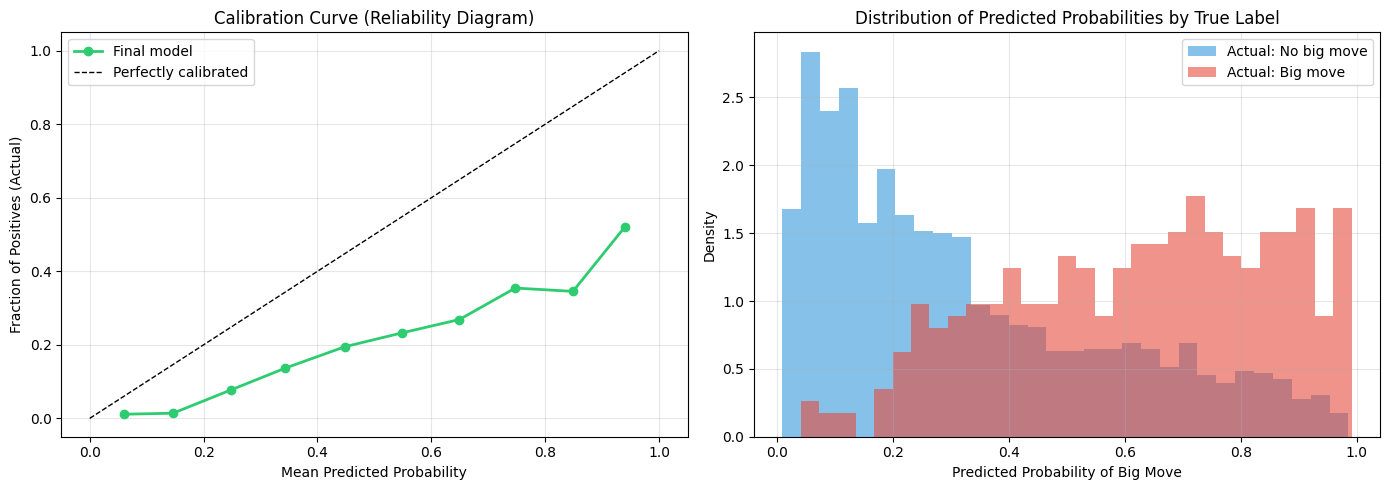

Brier score: 0.1716 (lower is better; random baseline ~0.1243)

Expected Calibration Error (ECE): 0.2213

The model shows moderate miscalibration. Consider applying Platt scaling
(sklearn CalibratedClassifierCV) to improve probability estimates.


In [12]:
# Calibration curve for the final model

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: calibration curve
prob_true, prob_pred = calibration_curve(y_test, y_prob_test, n_bins=10, strategy='uniform')

axes[0].plot(prob_pred, prob_true, 'o-', color='#2ECC71', linewidth=2, label='Final model')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Perfectly calibrated')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives (Actual)')
axes[0].set_title('Calibration Curve (Reliability Diagram)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: distribution of predicted probabilities
axes[1].hist(
    y_prob_test[y_test == 0], bins=30, alpha=0.6, color='#3498db',
    label='Actual: No big move', density=True
)
axes[1].hist(
    y_prob_test[y_test == 1], bins=30, alpha=0.6, color='#e74c3c',
    label='Actual: Big move', density=True
)
axes[1].set_xlabel('Predicted Probability of Big Move')
axes[1].set_ylabel('Density')
axes[1].set_title('Distribution of Predicted Probabilities by True Label')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/updated/calibration_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Brier score (lower is better; 0 = perfect)
from sklearn.metrics import brier_score_loss
brier = brier_score_loss(y_test, y_prob_test)
print(f"Brier score: {brier:.4f} (lower is better; random baseline ~{y_test.mean() * (1 - y_test.mean()):.4f})")
print()

# Expected Calibration Error (ECE)
ece = np.sum(np.abs(prob_true - prob_pred) * np.histogram(y_prob_test, bins=10, range=(0,1))[0][:len(prob_true)] / len(y_test))
print(f"Expected Calibration Error (ECE): {ece:.4f}")
print()

if ece > 0.05:
    print("The model shows moderate miscalibration. Consider applying Platt scaling")
    print("(sklearn CalibratedClassifierCV) to improve probability estimates.")
else:
    print("The model appears reasonably well-calibrated.")

---
## Summary of Improvements

| # | Improvement | Finding |
|---|---|---|
| 1 | **Prediction Timing** | Model is designed for after-market-close usage. No look-ahead leakage confirmed via correlation checks and manual return verification. |
| 2 | **Feature Importance** | Inspected logistic regression coefficients for both numeric and TF-IDF features to validate the model learns interpretable patterns. |
| 3 | **Threshold Justification** | 5% threshold corresponds to ~90th percentile of daily absolute returns -- captures genuinely unusual moves while maintaining sufficient positive samples (~10.9% base rate). |
| 4 | **Robustness Check** | Compared model performance across TF-IDF dimensionalities (500 to 10,000) to verify the text signal is robust and not an artifact of overfitting to rare n-grams. |
| 5 | **Sentiment Comparison** | Built a WSB-specific sentiment lexicon and compared against vanilla VADER. TF-IDF likely already captures domain language; for production, FinBERT would be the upgrade path. |
| 6 | **Calibration Analysis** | Produced reliability diagram, Brier score, and ECE to assess whether predicted probabilities are trustworthy for downstream decision-making. |